# 순환 신경망(RNN/LSTM) 기반 감성 분석 (알라딘 도서 리뷰)
1. 데이터 준비
2. 모델 구조 및 학습 설계 (구축)
3. 모델 학습
4. 모델 평가
5. 예측
6. 배포 (저장, 재사용)

## 1. 데이터 준비
    1-1. 데이터 로딩
    1-2. 데이터 전처리
    1-3. 데이터 분리
    1-4. 학습용 데이터 준비
    1-5. 테스트용 데이터 준비

### 1-1. 데이터 로딩
* 알라딘 리뷰 정제본 part01~04 (book_title, review_content, rating) 를 합쳐서 사용

In [1]:
# 알라딘 리뷰 데이터 로딩 (part01~04 합치기)
import pandas as pd
import glob, os

DATA_DIR = r"C:\\Users\\user\\Desktop\\크롤링 내용"
files = sorted(glob.glob(os.path.join(DATA_DIR, "aladin_reviews_clean_part0[1-4].csv")))
review_df = pd.concat([pd.read_csv(f, encoding='utf-8-sig') for f in files], ignore_index=True)
review_df.head()

,book_title,review_content,rating
0,2026 제17회 젊은작가상 수상작품집,도대체 한작품으로 상을 몇개씩 받고 책을 몇권씩 내는 거냐? 이렇게 인물이 없나?,1
1,2026 제17회 젊은작가상 수상작품집,이번 표지 역대급으로 예쁜...!! 아는 작품은 받을 만하다고 고개를 끄덕거리게 되...,5
2,2026 제17회 젊은작가상 수상작품집,이미상의 소설은 늘 나를 설레게 하지! 어서 오세요!,5
3,2026 제17회 젊은작가상 수상작품집,새로운 이름들은 설레는 마음으로 익숙한 이름들은 기대를 갖고 읽게 됩니다 남의현 작...,5
4,2026 제17회 젊은작가상 수상작품집,라인업이 너무 좋네요...,5


In [2]:
# 평점(rating) 분포 확인
review_df.rating.value_counts().sort_index()

rating
1     14435
2     11398
3     52632
4    195350
5    751938
Name: count, dtype: int64

In [3]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025753 entries, 0 to 1025752
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   book_title      1025752 non-null  object
 1   review_content  1025753 non-null  object
 2   rating          1025753 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 23.5+ MB


### 1-2. 데이터 전처리
- 평점 기반 정답(label) 생성
- 결측치 제거
- 정제 (한글만 남기고 모두 삭제)
- 중복치 제거
- 클래스 불균형 보정 (균형 샘플링)
- 형태소 분석기로 토큰화

#### 1-2-1. 정답(label) 생성
* 평점 1~2점 → 부정(0), 3점 → 중립(1), 4~5점 → 긍정(2)
* 3개 클래스(부정/중립/긍정) 다중 분류

In [4]:
# 평점으로 3개 클래스 레이블 생성 (0=부정, 1=중립, 2=긍정)
def to_label(r):
    if r >= 4: return 2   # 긍정
    if r == 3: return 1   # 중립
    return 0              # 부정
review_df['label'] = review_df.rating.apply(to_label)
review_df.label.value_counts().sort_index()

label
0     25833
1     52632
2    947288
Name: count, dtype: int64

#### 1-2-2. 결측치 제거

In [5]:
# 결측치 확인
review_df.isnull().sum()

book_title        1
review_content    0
rating            0
label             0
dtype: int64

In [6]:
# review_content 결측치 제거
review_df.dropna(subset=['review_content'], inplace=True)
review_df.isnull().sum()

book_title        1
review_content    0
rating            0
label             0
dtype: int64

#### 1-2-3. 정제
* 한글과 공백을 제외한 문자는 공백으로 치환하여 제거
* 한글이 없었던 리뷰는 공백만 남으므로, 결측치로 만들어 삭제 처리

In [7]:
import re
# 한글과 공백 제외하고 모두 공백으로 치환
review_df['clean_review'] = review_df.review_content.apply(lambda x : re.sub('[^ 가-힣]+', ' ', str(x)))
# 문장 앞쪽 공백 제거
review_df.clean_review = review_df.clean_review.apply(lambda x : re.sub('^ +', '', x))
# 빈 문자열("")은 결측치로 변환
review_df.clean_review = review_df.clean_review.replace('', None)
review_df.head()

,book_title,review_content,rating,label,clean_review
0,2026 제17회 젊은작가상 수상작품집,도대체 한작품으로 상을 몇개씩 받고 책을 몇권씩 내는 거냐? 이렇게 인물이 없나?,1,0,도대체 한작품으로 상을 몇개씩 받고 책을 몇권씩 내는 거냐 이렇게 인물이 없나
1,2026 제17회 젊은작가상 수상작품집,이번 표지 역대급으로 예쁜...!! 아는 작품은 받을 만하다고 고개를 끄덕거리게 되...,5,2,이번 표지 역대급으로 예쁜 아는 작품은 받을 만하다고 고개를 끄덕거리게 되고 새...
2,2026 제17회 젊은작가상 수상작품집,이미상의 소설은 늘 나를 설레게 하지! 어서 오세요!,5,2,이미상의 소설은 늘 나를 설레게 하지 어서 오세요
3,2026 제17회 젊은작가상 수상작품집,새로운 이름들은 설레는 마음으로 익숙한 이름들은 기대를 갖고 읽게 됩니다 남의현 작...,5,2,새로운 이름들은 설레는 마음으로 익숙한 이름들은 기대를 갖고 읽게 됩니다 남의현 작...
4,2026 제17회 젊은작가상 수상작품집,라인업이 너무 좋네요...,5,2,라인업이 너무 좋네요


In [8]:
# 정제 후 결측치 확인
review_df.clean_review.isnull().sum()

np.int64(157)

In [9]:
# 결측치 제거
review_df.dropna(subset=['clean_review'], inplace=True)
review_df.clean_review.isnull().sum()

np.int64(0)

#### 1-2-4. 중복치 제거

In [10]:
# 중복치 확인
review_df.clean_review.duplicated().sum()

np.int64(290)

In [11]:
# 중복치 제거
review_df.drop_duplicates(subset=['clean_review'], inplace=True)
review_df.clean_review.duplicated().sum()

np.int64(0)

#### 1-2-5. 클래스 불균형 보정 (균형 샘플링)
* 알라딘 리뷰는 긍정(4~5점)이 90% 이상으로 매우 불균형함
* 가장 적은 클래스(부정) 수에 맞춰 세 클래스를 같은 수로 샘플링 → 균형 데이터 구성

In [12]:
# 클래스별 개수 확인
print(review_df.label.value_counts())
# 적은 클래스 수에 맞춰 균형 샘플링
n = review_df.label.value_counts().min()
review_df = review_df.groupby('label', group_keys=False).sample(n=n, random_state=42).reset_index(drop=True)
review_df.label.value_counts()

label
2    946907
1     52593
0     25806
Name: count, dtype: int64


label
0    25806
1    25806
2    25806
Name: count, dtype: int64

#### 1-2-6. 토큰화

In [13]:
# 형태소 분석기 적용 (Okt)
from konlpy.tag import Okt
from tqdm import tqdm
tqdm.pandas()

review_df['tokens'] = review_df.clean_review.progress_apply(Okt().morphs)

100%|██████████| 77418/77418 [07:51<00:00, 164.17it/s]


In [14]:
review_df['tokens_str'] = review_df.tokens.apply(lambda x : ' '.join(x))
review_df.head()

,book_title,review_content,rating,label,clean_review,tokens,tokens_str
0,역사의 역사,당신같이 극편향된 사고를 가진 인간이 역사를 논하다니..돈주고 보라해도 볼게 못되겠네요,1,0,당신같이 극편향된 사고를 가진 인간이 역사를 논하다니 돈주고 보라해도 볼게 못되겠네요,"[당신, 같이, 극, 편향, 된, 사고, 를, 가진, 인간, 이, 역사, 를, 논,...",당신 같이 극 편향 된 사고 를 가진 인간 이 역사 를 논 하다니 돈 주고 보라 해...
1,뛰어난 사진을 만드는 비결,사진을 시작해 보겠다고 제일 먼저 한일은 물론 카메라 구입.. ㅎㅎ 그 다음엔 사진...,2,0,사진을 시작해 보겠다고 제일 먼저 한일은 물론 카메라 구입 그 다음엔 사진 관...,"[사진, 을, 시작, 해, 보겠다고, 제일, 먼저, 한일, 은, 물론, 카메라, 구...",사진 을 시작 해 보겠다고 제일 먼저 한일 은 물론 카메라 구입 그 다음 엔 사진 ...
2,영업의 신,그닥 묵직한 내용은 아닌 듯합니다,1,0,그닥 묵직한 내용은 아닌 듯합니다,"[그닥, 묵직한, 내용, 은, 아닌, 듯, 합니다]",그닥 묵직한 내용 은 아닌 듯 합니다
3,김병완의 책 쓰기 혁명,구체적인 내용이 없고문장도 좋지않다.,1,0,구체적인 내용이 없고문장도 좋지않다,"[구체, 적, 인, 내용, 이, 없고, 문장, 도, 좋지, 않다]",구체 적 인 내용 이 없고 문장 도 좋지 않다
4,타로카드 매트릭스,이 책 진짜 별로예요. 타로 기본 공부가 시급해 보여요. 별 하니도 아까움,1,0,이 책 진짜 별로예요 타로 기본 공부가 시급해 보여요 별 하니도 아까움,"[이, 책, 진짜, 별로, 예요, 타로, 기본, 공부, 가, 시급해, 보여요, 별,...",이 책 진짜 별로 예요 타로 기본 공부 가 시급해 보여요 별 하니 도 아까 움


In [15]:
# 전처리 결과 저장 (재사용용)
review_df.to_csv(os.path.join(DATA_DIR, 'aladin_review_ing.csv'))

### 1-3. 데이터 분리
* 정답 데이터의 분포를 유지하며 학습/테스트로 분리 (stratify=label)

In [16]:
# 입력 데이터와 정답 데이터 추출 (list)
review_list = list(review_df.tokens_str)
label_list = list(review_df.label)

In [17]:
# label 분포 확인
review_df.label.value_counts()

label
0    25806
1    25806
2    25806
Name: count, dtype: int64

<Axes: xlabel='label'>

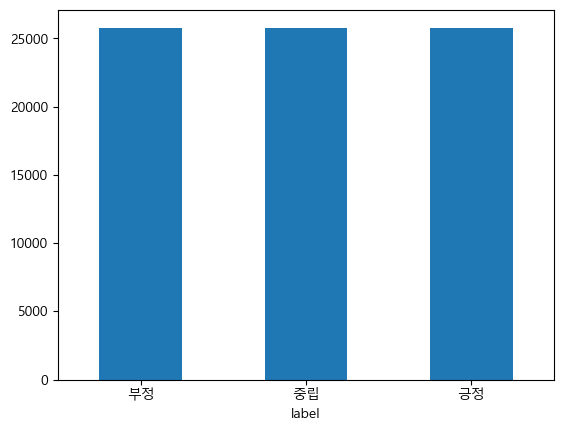

In [18]:
# 막대그래프로 그려보기 (부정/중립/긍정 3개 클래스)
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
name_map = {0: '부정', 1: '중립', 2: '긍정'}
review_df.label.map(name_map).value_counts().reindex(['부정', '중립', '긍정']).plot(kind='bar', rot=0)

In [19]:
# 학습 데이터와 테스트 데이터 분리
from sklearn.model_selection import train_test_split

review_train, review_test, label_train, label_test = train_test_split(
    review_list, label_list, test_size=0.1, stratify=label_list, random_state=42)
len(review_train), len(review_test), len(label_train), len(label_test)

(69676, 7742, 69676, 7742)

### 1-4. 학습 데이터 준비 for tensorflow
    1-4-1. Integer Encoding을 위한 tokenizer 생성
    1-4-2. 입력 데이터 Integer Encoding
    1-4-3. 입력 데이터 Padding
    1-4-4. 정답 데이터 원핫인코딩

#### 1-4-1. Integer Encoding을 위한 tokenizer 생성
* num_words = 사용할 단어 수(vocab_size) + 1 (0은 OOV/패딩에 할당)

In [20]:
# 단어 수 제한 없이 Tokenizer 생성하여 단어 수 확인
from tensorflow.keras.preprocessing.text import Tokenizer
test_tokenizer = Tokenizer()
test_tokenizer.fit_on_texts(review_train)
list(test_tokenizer.word_index.items())[:10]

[('이', 1),
 ('을', 2),
 ('의', 3),
 ('에', 4),
 ('책', 5),
 ('를', 6),
 ('가', 7),
 ('은', 8),
 ('들', 9),
 ('는', 10)]

In [21]:
from lib.my_utils import word_status_below_threshold
# 등장 빈도수를 threshold로 설정하여 버릴 단어가 차지하는 비율 확인
threshold = 3
word_status_below_threshold(test_tokenizer, threshold)

=== 빈도수가 3번 이상인 단어만 사용하는 경우 ====
전체 단어 : 136,448개 5,042,090번
희귀 단어 : 84,357개 (61.82%) 102,438번 (2.03%)
사용할 단어 : 52,091개 (38.18%)    4,939,652번 (97.97%)


In [22]:
# 단어 수를 제한하여 tokenizer 생성
from tensorflow.keras.preprocessing.text import Tokenizer
vocab_size = 30000
num_words = vocab_size + 1
tokenizer = Tokenizer(num_words=num_words)
tokenizer.fit_on_texts(review_train)
len(tokenizer.word_index)

136448

#### 1-4-2. 입력 데이터 Integer Encoding
* 제한된 단어에만 index를 부여하므로, 희귀 단어로만 구성된 리뷰는 길이가 0이 됨 → 제거

In [23]:
# 입력 데이터 Integer Encoding
encoded_review_train = tokenizer.texts_to_sequences(review_train)
print(encoded_review_train[:5])

[[137, 1537, 1, 5, 8, 255, 330, 22, 1476, 13, 263, 15, 3061, 309, 6, 1469, 42, 2135, 1, 7, 2397, 30, 171, 164, 56, 46, 577, 3805, 3187, 3, 11127, 6, 2, 14912, 4194, 6489, 23, 1957, 111, 86, 118, 22, 2464, 2409, 354, 62, 3, 509, 2, 4361, 58, 1262, 2135, 2039, 218, 2, 682, 5, 2, 178, 309, 6, 987, 24, 36, 1590, 3, 274, 1, 84, 38, 31, 1241, 238, 13515, 741, 4, 4320, 438, 1387, 98, 2465, 2135, 1, 54, 214, 89, 2211, 6, 124, 10, 2397, 30, 4517, 20451, 13, 21705, 3, 3805, 3187, 3, 1003, 8, 78, 254, 18, 7367, 436, 1857, 1874, 2, 12, 14], [15482, 4672, 10, 116, 8, 421, 4, 18349, 560, 2871, 446, 1, 2281, 352, 7, 446, 2, 1740, 421, 3, 1162, 8, 1307, 8, 506, 8, 351, 322, 5362, 3649, 94, 225, 15, 13118, 11432, 30, 12018, 3, 3713, 195, 4, 2668, 13, 40, 510, 1, 3089, 13, 5362, 3649, 94, 225, 119, 3354, 4, 29304, 5362, 3649, 22, 1710, 85, 40, 1212, 17522, 86, 11, 8, 303, 1251, 6, 19, 11, 22, 112, 493, 11, 8, 1251, 6, 33, 11, 138, 2595, 400, 2, 1497, 108, 13, 11, 138, 165, 1, 78, 11, 61, 27, 1, 397, 73,

In [24]:
# 길이가 0인 리뷰의 index 추출
null_index = [index for index, review in enumerate(encoded_review_train) if len(review) < 1]
print(len(null_index))
null_index[:10]

6


[5385, 10665, 12120, 35659, 37782, 47070]

In [25]:
# 길이가 1 이상인 리뷰만으로 학습 데이터 재구성
new_review_train = [review for index, review in enumerate(encoded_review_train) if index not in null_index]
new_label_train = [label for index, label in enumerate(label_train) if index not in null_index]
len(new_review_train), len(new_label_train)

(69670, 69670)

#### 1-4-3. 입력 데이터 padding
* 입력 데이터의 길이(max_len)를 정하여 padding

array([[<Axes: title={'center': '0'}>]], dtype=object)

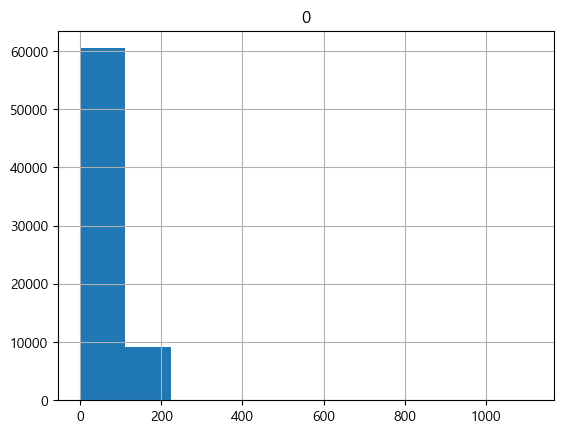

In [26]:
# 리뷰 길이 분포 확인 (히스토그램)
len_df = pd.DataFrame([len(review) for review in new_review_train])
len_df.hist()

In [27]:
# 길이 통계 확인
len_df.describe()

,0
count,69670.000000
mean,69.636013
std,40.680072
min,1.000000
25%,28.000000
50%,84.000000
75%,107.000000
max,1112.000000


In [28]:
from lib.my_utils import text_len_status_below_maxlen
# 길이가 max_len 이하인 데이터의 비중 확인
max_len = 60
text_len_status_below_maxlen(new_review_train, max_len)

텍스트의 토큰 수가 60 이하인 텍스트 : 29,854개 (42.85%)


In [29]:
# max_len 길이로 입력 데이터 padding
from tensorflow.keras.preprocessing.sequence import pad_sequences
train_X = pad_sequences(new_review_train, maxlen=max_len)
len(train_X), train_X[:2]

(69670,
 array([[ 2039,   218,     2,   682,     5,     2,   178,   309,     6,
           987,    24,    36,  1590,     3,   274,     1,    84,    38,
            31,  1241,   238, 13515,   741,     4,  4320,   438,  1387,
            98,  2465,  2135,     1,    54,   214,    89,  2211,     6,
           124,    10,  2397,    30,  4517, 20451,    13, 21705,     3,
          3805,  3187,     3,  1003,     8,    78,   254,    18,  7367,
           436,  1857,  1874,     2,    12,    14],
        [  510,     1,  3089,    13,  5362,  3649,    94,   225,   119,
          3354,     4, 29304,  5362,  3649,    22,  1710,    85,    40,
          1212, 17522,    86,    11,     8,   303,  1251,     6,    19,
            11,    22,   112,   493,    11,     8,  1251,     6,    33,
            11,   138,  2595,   400,     2,  1497,   108,    13,    11,
           138,   165,     1,    78,    11,    61,    27,     1,   397,
            73,  1308,  9950,    42,    12,    14]], dtype=int32))

#### 1-4-4. 정답 데이터 one-hot encoding

In [30]:
from tensorflow.keras.utils import to_categorical
train_y = to_categorical(new_label_train)
len(train_y), train_y[:2]

(69670,
 array([[0., 1., 0.],
        [0., 1., 0.]]))

### 1-5. 테스트 데이터 준비
    1-5-1. 입력 데이터 Integer Encoding (결측치 제거)
    1-5-2. 입력 데이터 padding
    1-5-3. 정답 데이터 one-hot encoding

In [31]:
# 입력 데이터 Integer Encoding
encoded_review_test = tokenizer.texts_to_sequences(review_test)
print(encoded_review_test[:2])

[[4951, 2018, 6191, 3, 96, 1244, 12, 530, 4951, 2018, 6191, 1238, 6369, 243, 679, 247, 6176, 453, 2, 29739, 133, 564, 142, 1277, 29, 6, 12, 3547, 2793], [150, 419, 1, 4865, 1372, 41, 2, 110, 129, 16815]]


In [32]:
# 길이가 0인 리뷰 제거하여 테스트 데이터 재구성
null_index = [index for index, review in enumerate(encoded_review_test) if len(review) == 0]
new_review_test = [review for index, review in enumerate(encoded_review_test) if index not in null_index]
new_label_test = [label for index, label in enumerate(label_test) if index not in null_index]
len(new_review_test), len(new_label_test)

(7741, 7741)

In [33]:
# 입력 데이터 padding
from tensorflow.keras.preprocessing.sequence import pad_sequences
test_X = pad_sequences(new_review_test, maxlen=max_len)
len(test_X), test_X[:2]

(7741,
 array([[    0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,  4951,  2018,  6191,     3,    96,
          1244,    12,   530,  4951,  2018,  6191,  1238,  6369,   243,
           679,   247,  6176,   453,     2, 29739,   133,   564,   142,
          1277,    29,     6,    12,  3547,  2793],
        [    0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,   150,   419,     1,  4865,
          1372,    41,     2,   110,   129, 16815]], dtype=int32))

In [34]:
# 정답 데이터 one-hot encoding
from tensorflow.keras.utils import to_categorical
test_y = to_categorical(new_label_test)
len(test_y), test_y[:5]

(7741,
 array([[0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.]]))

## 2. 모델 구축 및 컴파일

In [35]:
# 신경망 구조 설계
from tensorflow.keras.layers import Embedding, LSTM, Dense

input_units = num_words      # 사용한 feature 수 = 단어 수
embedding_dim = 32
lstm_units = 64
dense_units = 16
output_units = 3             # 분류 수 3개 (부정/중립/긍정)

rnn_model = [
    Embedding(input_units, embedding_dim),
    LSTM(lstm_units),
    Dense(dense_units, activation='tanh'),
    Dense(output_units, activation='softmax')
]

In [36]:
# 신경망 구조 생성
from tensorflow.keras.models import Sequential
model = Sequential(rnn_model)
model.build(input_shape=(None, max_len))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 60, 32)         │       960,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 985,955 (3.76 MB)

 Trainable params: 985,955 (3.76 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# 모델 학습 설계
from tensorflow.keras.optimizers import RMSprop
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer=RMSprop(learning_rate=0.001))

In [38]:
# EarlyStopping, ModelCheckpoint 설정
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
es = EarlyStopping(monitor='val_loss', mode='min', patience=3, verbose=1)
checkpoint_file = './model/best_model_aladin.keras'
mc = ModelCheckpoint(checkpoint_file, monitor='val_loss', mode='min', save_best_only=True)

## 3. 모델 학습

In [39]:
# 모델 학습
history = model.fit(train_X, train_y, epochs=20, batch_size=128,
                    validation_split=0.1, callbacks=[es, mc])

Epoch 1/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.4977 - loss: 0.9869 - val_accuracy: 0.5736 - val_loss: 0.8813
Epoch 2/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.6142 - loss: 0.8250 - val_accuracy: 0.5912 - val_loss: 0.8539
Epoch 3/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.6548 - loss: 0.7611 - val_accuracy: 0.5912 - val_loss: 0.8567
Epoch 4/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.6919 - loss: 0.7038 - val_accuracy: 0.5872 - val_loss: 0.8784
Epoch 5/20
490/490 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.7184 - loss: 0.6602 - val_accuracy: 0.5892 - val_loss: 0.9000
Epoch 5: early stopping


## 4. 모델 평가

In [40]:
# 저장된 best 모델 가중치 로딩
model.load_weights(checkpoint_file)

In [41]:
# 테스트 데이터로 평가
loss, acc = model.evaluate(test_X, test_y)
loss, acc

242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6176 - loss: 0.8212


(0.8313873410224915, 0.6125823259353638)

In [42]:
# predict로 예측값 구하기
import numpy as np
preds = model.predict(test_X)
result = [np.argmax(pred) for pred in preds]
result[:20]

242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


[np.int64(0),
 np.int64(0),
 np.int64(2),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(1),
 np.int64(0),
 np.int64(2),
 np.int64(0),
 np.int64(2),
 np.int64(0),
 np.int64(2),
 np.int64(2),
 np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(1),
 np.int64(2),
 np.int64(1)]

In [43]:
# classification_report로 평가 (정확도 말고 macro-F1 확인)
from sklearn.metrics import classification_report
print(classification_report(new_label_test, result, target_names=['부정', '중립', '긍정']))

              precision    recall  f1-score   support

          부정       0.72      0.67      0.69      2579
          중립       0.50      0.47      0.48      2581
          긍정       0.62      0.70      0.66      2581

    accuracy                           0.61      7741
   macro avg       0.61      0.61      0.61      7741
weighted avg       0.61      0.61      0.61      7741



## 5. 예측

In [44]:
# 입력된 리뷰의 긍/부정 판단 함수
from konlpy.tag import Okt
def analyze_sentiment(text):
    # 전처리 -> 형태소 분석 -> Integer Encoding -> Padding
    tokens = Okt().morphs(text)
    encoded_text = tokenizer.texts_to_sequences([tokens])
    X = pad_sequences(encoded_text, maxlen=max_len)
    preds = model.predict(X, verbose=0)
    labels = ['부정', '중립', '긍정']
    result_index = np.argmax(preds[0])
    return labels[result_index], preds[0][result_index]

In [45]:
# 함수 테스트 (도서 리뷰 예시)
reviews = [
    '정말 감동적이고 다시 읽고 싶은 책이에요',
    '내용도 부실하고 시간 낭비였습니다',
    '작가의 문장력이 뛰어나서 술술 읽힌다',
    '돈이 아깝다 추천하지 않아요',
    '올해 읽은 책 중 최고의 인생책',
    '번역이 너무 어색해서 읽기 힘들었어요',
    '그냥 무난하게 읽을 만한 책이에요'
]
for review in reviews:
    result, prob = analyze_sentiment(review)
    print(f'{review} --> {result}({prob*100:.2f}%)')

정말 감동적이고 다시 읽고 싶은 책이에요 --> 긍정(80.90%)
내용도 부실하고 시간 낭비였습니다 --> 부정(87.12%)
작가의 문장력이 뛰어나서 술술 읽힌다 --> 긍정(53.46%)
돈이 아깝다 추천하지 않아요 --> 부정(90.80%)
올해 읽은 책 중 최고의 인생책 --> 긍정(69.98%)
번역이 너무 어색해서 읽기 힘들었어요 --> 부정(82.36%)
그냥 무난하게 읽을 만한 책이에요 --> 긍정(65.40%)


## 6. 배포 (모델 저장 및 재사용)
    6-1. 모델 저장
    6-2. SentimentAnalyzer 클래스 구현
        * 저장된 모델 로딩 및 사용

### 6-1. 모델 저장

In [46]:
# keras 학습 모델 저장
model.save('./model/sa_model_aladin.keras')

In [47]:
# Integer Encoding용 tokenizer 직렬화
import joblib
joblib.dump(tokenizer, './model/sa_tokenizer_aladin.pkl')

['./model/sa_tokenizer_aladin.pkl']

### 6-2. SentimentAnalyzer 클래스 구현
- 객체 생성 시 예측 모델, Integer Encoder 로딩
- 한국어 형태소 분석기 정의
- 입력된 리뷰의 긍/부정 판단 함수

In [48]:
from konlpy.tag import Okt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
import joblib
import numpy as np

class SentimentAnalyzer:
    def __init__(self, model_file, tokenizer_file, max_len=60):
        try:
            self.model = load_model(model_file)
        except FileExistsError:
            print(f'모델 파일 {model_file}이 없습니다.')
        try:
            self.tokenizer = joblib.load(tokenizer_file)
        except FileExistsError:
            print(f'토크나이저 파일 {tokenizer_file}이 없습니다.')
        self.morphs = Okt().morphs
        self.max_len = max_len

    def analyze_sentiment(self, text):
        # 전처리 -> 형태소 분석 -> Integer Encoding -> Padding
        tokens = self.morphs(text)
        encoded_text = self.tokenizer.texts_to_sequences([tokens])
        X = pad_sequences(encoded_text, maxlen=self.max_len)
        preds = self.model.predict(X, verbose=0)
        labels = ['부정', '중립', '긍정']
        result_index = np.argmax(preds[0])
        return labels[result_index], preds[0][result_index]

In [49]:
# 클래스 사용 예시
analyzer = SentimentAnalyzer('./model/sa_model_aladin.keras', './model/sa_tokenizer_aladin.pkl', max_len=60)
analyzer.analyze_sentiment('이 책 정말 강력 추천합니다')

('긍정', np.float32(0.76254547))